<h1 style="color:blue; text-align:center;">Student Performance Analysis</h1>

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("student_performance.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   student_id     30 non-null     int64  
 1   gender         28 non-null     object 
 2   math_score     27 non-null     float64
 3   reading_score  28 non-null     float64
 4   writing_score  26 non-null     float64
 5   attendance     27 non-null     float64
 6   study_hours    29 non-null     float64
dtypes: float64(5), int64(1), object(1)
memory usage: 1.8+ KB


In [4]:
df.isnull().sum()

student_id       0
gender           2
math_score       3
reading_score    2
writing_score    4
attendance       3
study_hours      1
dtype: int64

In [5]:
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])  
df['math_score'] = df['math_score'].fillna(df['math_score'].mean())

In [6]:
df.isnull().sum()

student_id       0
gender           0
math_score       0
reading_score    2
writing_score    4
attendance       3
study_hours      1
dtype: int64

In [7]:
df['reading_score'] = df['reading_score'].fillna(df['reading_score'].mean())
df['writing_score'] = df['writing_score'].fillna(df['writing_score'].mean())

In [8]:
df.isnull().sum()

student_id       0
gender           0
math_score       0
reading_score    0
writing_score    0
attendance       3
study_hours      1
dtype: int64

In [9]:
df['attendance'] = df['attendance'].fillna(df['attendance'].mean())
df['study_hours'] = df['study_hours'].fillna(df['study_hours'].mean())

In [10]:
df.isnull().sum()

student_id       0
gender           0
math_score       0
reading_score    0
writing_score    0
attendance       0
study_hours      0
dtype: int64

In [11]:
df['average_score'] = np.mean(df[['math_score','reading_score','writing_score']] , axis = 1)

In [12]:
class_average = np.mean(df['average_score'])
print(class_average)

69.07227648894316


In [13]:
highest_math = np.max(df['math_score'])
lowest_math = np.min(df['math_score'])
print("highest :",highest_math , "and", "lowest : ",lowest_math)

highest : 95.0 and lowest :  33.0


In [14]:
df['pass_fail'] = np.where(df['average_score'] >= 50 , 'pass','fail')

In [15]:
df.head(10)

,student_id,gender,math_score,reading_score,writing_score,attendance,study_hours,average_score,pass_fail
0,1,Male,78.000000,82.000000,75.000000,90.000000,4.00000,78.333333,pass
1,2,Female,65.000000,70.000000,68.461538,85.000000,3.00000,67.820513,pass
2,3,Male,92.000000,88.000000,90.000000,95.000000,6.00000,90.000000,pass
3,4,Female,55.000000,60.000000,58.000000,72.000000,2.00000,57.666667,pass
4,5,Female,48.000000,70.607143,52.000000,68.000000,1.00000,56.869048,pass
5,6,Male,35.000000,40.000000,38.000000,60.000000,3.62069,37.666667,fail
6,7,Female,88.000000,92.000000,91.000000,96.000000,7.00000,90.333333,pass
7,8,Male,73.000000,75.000000,68.461538,82.000000,4.00000,72.153846,pass
8,9,Female,60.000000,63.000000,65.000000,80.185185,3.00000,62.666667,pass
9,10,Male,68.148148,58.000000,55.000000,70.000000,2.00000,60.382716,pass


In [16]:
gender_avg = df.groupby('gender')['average_score'].mean()

In [17]:
gender_avg

gender
Female    72.933833
Male      64.659069
Name: average_score, dtype: float64

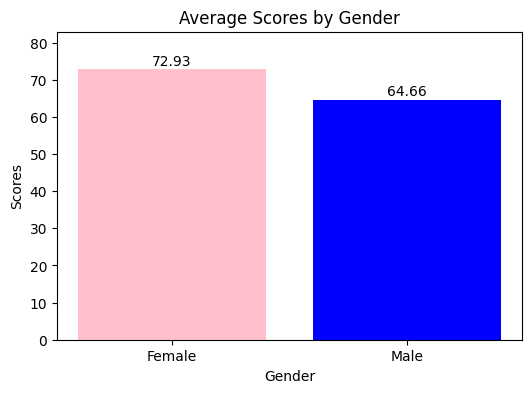

In [18]:
plt.figure(figsize = (6,4))
bars = plt.bar(gender_avg.index , gender_avg.values , color = ['pink','blue'])
plt.title("Average Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Scores")
for bar in bars:
    yval = bar.get_height()  # bar ki height = score
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, round(yval,2), ha='center')

plt.ylim(0, max(gender_avg.values) + 10)
plt.show()





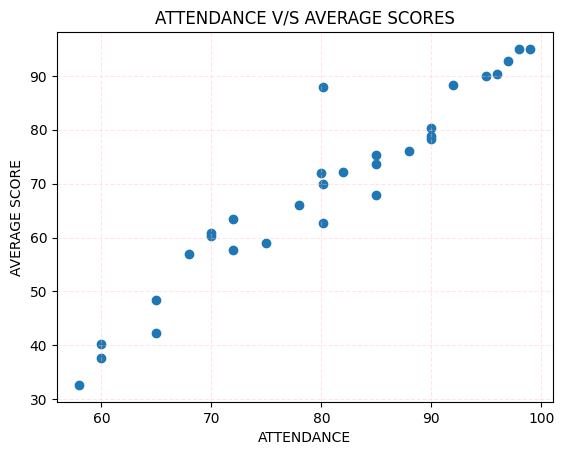

In [19]:
plt.scatter(df['attendance'],df['average_score'])
plt.xlabel('ATTENDANCE')
plt.ylabel('AVERAGE SCORE')
plt.title("ATTENDANCE V/S AVERAGE SCORES")
plt.grid(color = 'pink', alpha = 0.4 , linestyle = '--')
plt.show()

In [20]:
correlation = np.corrcoef(df['study_hours'], df['average_score'])[0, 1]
print("Correlation between Study Hours and Average Score:", correlation)


Correlation between Study Hours and Average Score: 0.8883734065890916


In [21]:
top10 = df.sort_values(by = 'average_score' , ascending = False).head(10)

In [22]:
print(top10[['student_id' , 'study_hours', 'attendance','average_score']])

    student_id  study_hours  attendance  average_score
10          11          6.0   98.000000      95.000000
29          30          7.0   99.000000      95.000000
22          23          6.0   97.000000      92.666667
6            7          7.0   96.000000      90.333333
2            3          6.0   95.000000      90.000000
15          16          6.0   92.000000      88.333333
25          26          5.0   80.185185      88.000000
20          21          4.0   90.000000      80.333333
13          14          5.0   90.000000      78.820513
0            1          4.0   90.000000      78.333333


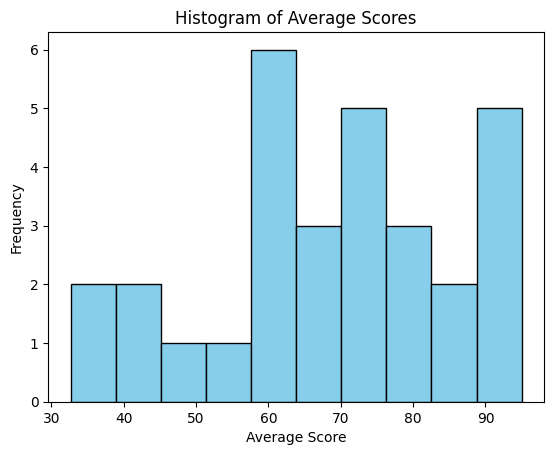

In [23]:
plt.hist(df['average_score'], bins=10, color='skyblue', edgecolor='black')
plt.xlabel('Average Score')
plt.ylabel('Frequency')
plt.title('Histogram of Average Scores')
plt.show()


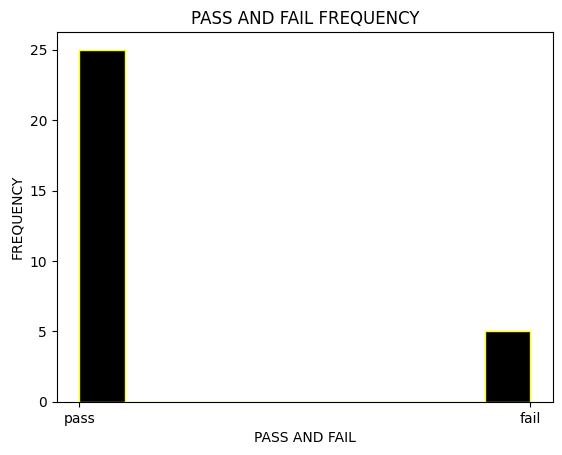

In [24]:
plt.hist(df['pass_fail'] , bins = 10 , color = 'black' , edgecolor = 'yellow')
plt.xlabel('PASS AND FAIL')
plt.ylabel('FREQUENCY')
plt.title('PASS AND FAIL FREQUENCY')
plt.show()

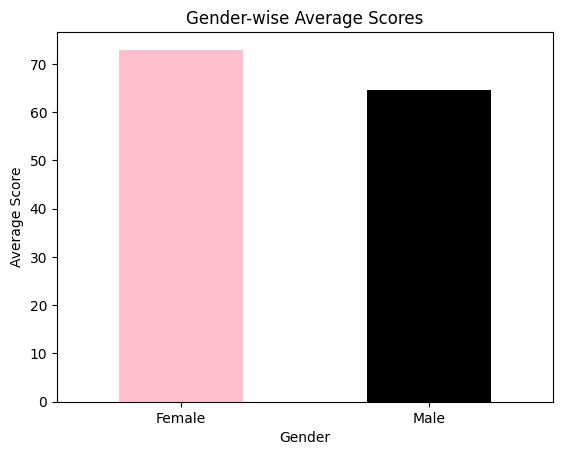

In [25]:
gender_avg.plot(kind  = 'bar' , color = ['pink','black'])
plt.xlabel('Gender')
plt.ylabel('Average Score')
plt.title('Gender-wise Average Scores')
plt.xticks(rotation = 0)
plt.show()

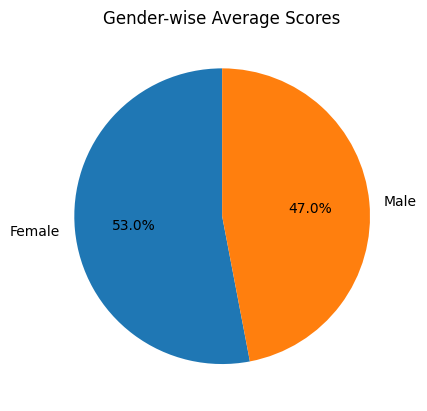

In [26]:
gender_avg.plot(kind = 'pie' , autopct = '%1.1f%%' , startangle = 90)
plt.title('Gender-wise Average Scores')
plt.ylabel('')
plt.show()

## Insights from Student Performance Analysis

1. Female students have higher average scores compared to male students.
2. Attendance shows a strong positive correlation with academic performance.
3. Students who study more hours generally score higher.
4. Top-performing students consistently have high attendance and study hours.
5. Study hours and attendance are key factors affecting student performance.


In [27]:
df.head()

,student_id,gender,math_score,reading_score,writing_score,attendance,study_hours,average_score,pass_fail
0,1,Male,78.0,82.000000,75.000000,90.0,4.0,78.333333,pass
1,2,Female,65.0,70.000000,68.461538,85.0,3.0,67.820513,pass
2,3,Male,92.0,88.000000,90.000000,95.0,6.0,90.000000,pass
3,4,Female,55.0,60.000000,58.000000,72.0,2.0,57.666667,pass
4,5,Female,48.0,70.607143,52.000000,68.0,1.0,56.869048,pass


In [30]:
df['total_score'] = df[['math_score','reading_score','writing_score']].sum(axis = 1)

In [31]:
df.head()

,student_id,gender,math_score,reading_score,writing_score,attendance,study_hours,average_score,pass_fail,total_score
0,1,Male,78.0,82.000000,75.000000,90.0,4.0,78.333333,pass,235.000000
1,2,Female,65.0,70.000000,68.461538,85.0,3.0,67.820513,pass,203.461538
2,3,Male,92.0,88.000000,90.000000,95.0,6.0,90.000000,pass,270.000000
3,4,Female,55.0,60.000000,58.000000,72.0,2.0,57.666667,pass,173.000000
4,5,Female,48.0,70.607143,52.000000,68.0,1.0,56.869048,pass,170.607143


In [32]:
conditions = [
    df['average_score'] >= 85,
    df['average_score'] >= 70,
    df['average_score'] >= 50
]
grades = np.select(conditions, ['A','B','C'], default = 'D')
df['grade'] = grades


In [34]:
df.head(30)

,student_id,gender,math_score,reading_score,writing_score,attendance,study_hours,average_score,pass_fail,total_score,grade
0,1,Male,78.000000,82.000000,75.000000,90.000000,4.00000,78.333333,pass,235.000000,B
1,2,Female,65.000000,70.000000,68.461538,85.000000,3.00000,67.820513,pass,203.461538,C
2,3,Male,92.000000,88.000000,90.000000,95.000000,6.00000,90.000000,pass,270.000000,A
3,4,Female,55.000000,60.000000,58.000000,72.000000,2.00000,57.666667,pass,173.000000,C
4,5,Female,48.000000,70.607143,52.000000,68.000000,1.00000,56.869048,pass,170.607143,C
5,6,Male,35.000000,40.000000,38.000000,60.000000,3.62069,37.666667,fail,113.000000,D
6,7,Female,88.000000,92.000000,91.000000,96.000000,7.00000,90.333333,pass,271.000000,A
7,8,Male,73.000000,75.000000,68.461538,82.000000,4.00000,72.153846,pass,216.461538,B
8,9,Female,60.000000,63.000000,65.000000,80.185185,3.00000,62.666667,pass,188.000000,C
9,10,Male,68.148148,58.000000,55.000000,70.000000,2.00000,60.382716,pass,181.148148,C


In [45]:
df['percentile_rank'] = df['average_score'].rank(pct=True) * 100

In [47]:
df.head()

,student_id,gender,math_score,reading_score,writing_score,attendance,study_hours,average_score,pass_fail,total_score,grade,percentile_rank
0,1,Male,78.0,82.000000,75.000000,90.0,4.0,78.333333,pass,235.000000,B,70.000000
1,2,Female,65.0,70.000000,68.461538,85.0,3.0,67.820513,pass,203.461538,C,46.666667
2,3,Male,92.0,88.000000,90.000000,95.0,6.0,90.000000,pass,270.000000,A,86.666667
3,4,Female,55.0,60.000000,58.000000,72.0,2.0,57.666667,pass,173.000000,C,23.333333
4,5,Female,48.0,70.607143,52.000000,68.0,1.0,56.869048,pass,170.607143,C,20.000000
